In [95]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import json
import numpy as np
from itertools import combinations

from utils.utils import (
    PYMOO_OK,
    RandomForestDiscovery,
    ScenarioDiscoveryOptimizer,
    TrajectoryAggregator,
    VulnerabilityAnalyzer,
)


In [96]:
# Enable automatic reloading of modules before executing cells
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [97]:
SCRIPT_DIR = os.getcwd()
PARENT_DIR = os.path.dirname(SCRIPT_DIR)
ML_DIR = os.path.join(PARENT_DIR, "ml_scripts")
DATA_DIR = os.path.join(ML_DIR, "output")
ENSEMBLE_DATA_DIR = os.path.join(DATA_DIR, "ensemble")
POST_PROCESSED_DATA_DIR = os.path.join(DATA_DIR, "2030_emissions")

In [102]:
# Load the data
run_id = 1773188058
iso_alpha_3 = "CRI"
df = pd.read_parquet(os.path.join(POST_PROCESSED_DATA_DIR, f"post_processed_projected_emissions_{run_id}.parquet"))
df.head()


,future_id,iso_alpha_3,year,con_edgar_ghg_mt_hp_trend
0,id_AFG_10,AFG,2022,28.630028
1,id_AFG_10,AFG,2023,29.511985
2,id_AFG_10,AFG,2024,30.435955
3,id_AFG_10,AFG,2025,31.448054
4,id_AFG_10,AFG,2026,32.404918


In [103]:
# Filter the data for the specific country
df = df[df["iso_alpha_3"] == iso_alpha_3]

### Class-Based Version
This notebook mirrors `scenario_discovery_simple.ipynb` but delegates core logic to classes in `scenario_discovery.utils`.

### Compute Vulnerability Indicator

In [104]:
# First compute percentage difference between final year and 2022.

df_pivot = VulnerabilityAnalyzer.compute_emissions_change(
    df,
    "2022",
    "2030",
    "con_edgar_ghg_mt_hp_trend",
)
df_pivot.head()


,future_id,iso_alpha_3,2022,2030,vulnerability_indicator
0,id_CRI_1,CRI,16.491604,18.181944,1
1,id_CRI_10,CRI,16.491604,18.093088,1
2,id_CRI_100,CRI,16.491604,18.201315,1
3,id_CRI_1000,CRI,16.491604,18.381028,1
4,id_CRI_101,CRI,16.491604,18.375543,1


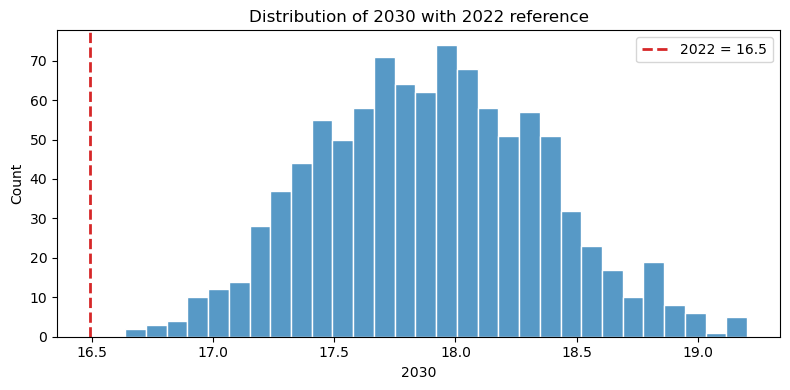

<Axes: title={'center': 'Distribution of 2030 with 2022 reference'}, xlabel='2030', ylabel='Count'>

In [105]:
VulnerabilityAnalyzer.plot_future_distribution_with_baseline(
    df_pivot,
    future_col="2030",
    baseline_col="2022",
)

In [72]:
df_pivot[df_pivot["vulnerability_indicator"] == 0]

,future_id,iso_alpha_3,2022,2030,vulnerability_indicator
1,id_BRA_10,BRA,1314.381605,1301.757410,0
4,id_BRA_101,BRA,1314.381605,1269.343863,0
5,id_BRA_102,BRA,1314.381605,1298.462184,0
6,id_BRA_103,BRA,1314.381605,1301.161074,0
7,id_BRA_104,BRA,1314.381605,1234.980248,0
...,...,...,...,...,...
987,id_BRA_99,BRA,1314.381605,1241.293661,0
989,id_BRA_991,BRA,1314.381605,1294.003801,0
990,id_BRA_993,BRA,1314.381605,1269.707898,0
991,id_BRA_994,BRA,1314.381605,1255.609542,0


/Users/tony/Documents/research_project/etpe_project/scenario_discovery/utils/utils.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=vuln_col, data=df, palette=palette, order=order, ax=ax_local)


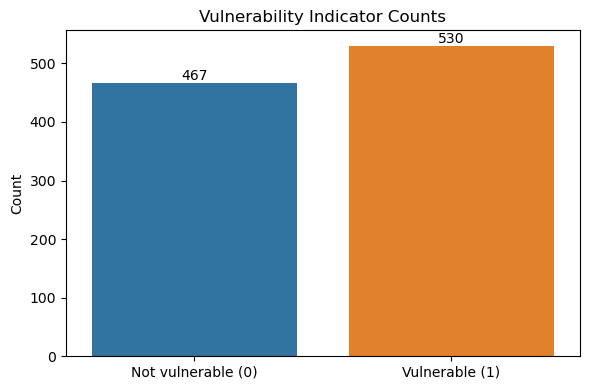

In [73]:
ax = VulnerabilityAnalyzer.plot_vulnerability_counts(df_pivot)


### Aggregate ARIMA data

In [74]:
# Load the projected data
ensemble_df = pd.read_parquet(os.path.join(ENSEMBLE_DATA_DIR, f"ensemble_arima_{run_id}.parquet"))
ensemble_df.head()

,iso_alpha_3,future_id,year,x_log_signed_con_edgar_ghg_mt,x_log_signed_con_solar,inc_has_efficiency_standard,inc_has_renewable_target,con_net_elec_imports_twh,x_log_signed_cap_civil_liberties_idx,inc_has_carbon_tax,...,cap_govt_effectiveness,con_ndgain_score,emissions_anchor_2022,years_since_2022,trend_year_interaction,em_lag_1y,em_trend_3y,em_trend_5y,em_volatility_5y,em_acceleration
0,AFG,id_AFG_1,2022,3.405119,0.048790,0.0,0.0,5.880000,0.040182,0.0,...,-1.880035,32.633596,NaN,0.0,NaN,3.399653,-0.022348,-0.028681,0.050438,0.006334
1,AFG,id_AFG_1,2023,3.406011,0.055667,0.0,0.0,6.009763,0.000000,0.0,...,-2.028122,32.452377,NaN,1.0,NaN,3.400199,-0.018481,-0.027746,0.049581,0.006627
2,AFG,id_AFG_1,2024,3.395691,0.063294,0.0,0.0,6.157955,0.000000,0.0,...,-2.189786,33.519214,NaN,2.0,NaN,3.400289,-0.019795,-0.026254,0.047960,0.006346
3,AFG,id_AFG_1,2025,3.384084,0.070110,0.0,0.0,6.515455,0.000000,0.0,...,-2.319343,33.014896,NaN,3.0,NaN,3.399257,-0.020584,-0.025285,0.046763,0.006171
4,AFG,id_AFG_1,2026,3.391456,0.071661,0.0,0.0,6.538660,0.000000,0.0,...,-2.482714,34.419108,NaN,4.0,NaN,3.398096,-0.021209,-0.026219,0.046283,0.006201


In [75]:
ensemble_df.columns

Index(['iso_alpha_3', 'future_id', 'year', 'x_log_signed_con_edgar_ghg_mt',
       'x_log_signed_con_solar', 'inc_has_efficiency_standard',
       'inc_has_renewable_target', 'con_net_elec_imports_twh',
       'x_log_signed_cap_civil_liberties_idx', 'inc_has_carbon_tax',
       'inc_has_ets', 'x_log_signed_inc_carbon_pricing_coverage',
       'con_forest_area_pct', 'con_agricultural_land_pct',
       'x_log_signed_con_nuclear', 'x_log_signed_con_electricity_access_pct',
       'inc_has_framework_law', 'x_log_signed_inc_n_climate_laws',
       'x_log_signed_inc_cumulative_climate_laws', 'con_fossil_share_elec_pct',
       'con_renewables_share_elec_pct', 'x_log_signed_con_primary_energy_twh',
       'x_log_signed_con_hydro', 'x_log_signed_con_demand',
       'x_log_signed_con_coal', 'x_log_signed_con_gas',
       'x_log_signed_con_demand_per_capita', 'cap_regulatory_quality',
       'cap_rule_of_law', 'cap_govt_effectiveness', 'con_ndgain_score',
       'emissions_anchor_2022', 'years_s

In [76]:
# Aggregate ensemble data so we only get a single row per future_id

# First we remove all emisssion-related variables to avoid any sort of leakage
emission_cols = [
    'x_log_signed_con_edgar_ghg_mt',
    'emissions_anchor_2022',
    'years_since_2022',
    'trend_year_interaction',
    'em_lag_1y',
    'em_trend_3y',
    'em_trend_5y',
    'em_volatility_5y',
    'em_acceleration'
]

ensemble_df = ensemble_df.drop(columns=emission_cols, errors='ignore')
ensemble_df = ensemble_df[ensemble_df["iso_alpha_3"] == iso_alpha_3]

rules_path = os.path.join(ML_DIR, 'config', 'variable_projection_rules.json')
trajectory_aggregator = TrajectoryAggregator(rules_path)
ensemble_agg_df = trajectory_aggregator.aggregate(ensemble_df)
ensemble_agg_df.head()


,future_id,iso_alpha_3,year_start,year_end,n_years,x_log_signed_con_solar__mean,x_log_signed_con_solar__std,x_log_signed_con_solar__min,x_log_signed_con_solar__max,x_log_signed_con_solar__last,...,cap_govt_effectiveness__last,cap_govt_effectiveness__delta,cap_govt_effectiveness__slope,con_ndgain_score__mean,con_ndgain_score__std,con_ndgain_score__min,con_ndgain_score__max,con_ndgain_score__last,con_ndgain_score__delta,con_ndgain_score__slope
0,id_BRA_1,BRA,2022,2030,9,4.370419,0.739453,3.273364,5.481882,5.481882,...,-0.704478,-0.116219,-0.006662,44.811385,2.080092,41.939368,47.616464,42.409995,-4.466254,-0.715908
1,id_BRA_10,BRA,2022,2030,9,5.618525,1.679982,3.273364,8.256533,8.256533,...,-0.721336,-0.133077,-0.022386,44.673946,1.099487,42.989589,46.876249,44.861931,-2.014318,-0.149991
2,id_BRA_100,BRA,2022,2030,9,6.245982,2.180631,3.273364,9.456158,9.456158,...,-0.683085,-0.094825,-0.021829,46.866446,1.069245,45.792453,49.131570,45.839221,-1.037028,-0.236209
3,id_BRA_1000,BRA,2022,2030,9,5.120046,1.260635,3.273364,7.060350,7.060350,...,-0.710531,-0.122271,-0.030747,44.218084,2.305957,40.976840,47.092543,41.621043,-5.255206,-0.819856
4,id_BRA_101,BRA,2022,2030,9,5.604818,1.671257,3.273364,8.182316,8.182316,...,-0.749355,-0.161095,-0.033375,44.433206,1.797463,40.311974,46.876249,40.311974,-6.564274,-0.479322


In [77]:
ensemble_agg_df.columns

Index(['future_id', 'iso_alpha_3', 'year_start', 'year_end', 'n_years',
       'x_log_signed_con_solar__mean', 'x_log_signed_con_solar__std',
       'x_log_signed_con_solar__min', 'x_log_signed_con_solar__max',
       'x_log_signed_con_solar__last',
       ...
       'cap_govt_effectiveness__last', 'cap_govt_effectiveness__delta',
       'cap_govt_effectiveness__slope', 'con_ndgain_score__mean',
       'con_ndgain_score__std', 'con_ndgain_score__min',
       'con_ndgain_score__max', 'con_ndgain_score__last',
       'con_ndgain_score__delta', 'con_ndgain_score__slope'],
      dtype='object', length=177)

In [78]:
df_pivot.head()

,future_id,iso_alpha_3,2022,2030,vulnerability_indicator
0,id_BRA_1,BRA,1314.381605,1376.594427,1
1,id_BRA_10,BRA,1314.381605,1301.757410,0
2,id_BRA_100,BRA,1314.381605,1417.362322,1
3,id_BRA_1000,BRA,1314.381605,1378.179618,1
4,id_BRA_101,BRA,1314.381605,1269.343863,0


In [79]:
merged_df = VulnerabilityAnalyzer.merge_ensemble_with_vulnerability(
    ensemble_agg_df,
    df_pivot,
    on_cols=["future_id", "iso_alpha_3"],
)
merged_df.head()


,future_id,iso_alpha_3,year_start,year_end,n_years,x_log_signed_con_solar__mean,x_log_signed_con_solar__std,x_log_signed_con_solar__min,x_log_signed_con_solar__max,x_log_signed_con_solar__last,...,con_ndgain_score__mean,con_ndgain_score__std,con_ndgain_score__min,con_ndgain_score__max,con_ndgain_score__last,con_ndgain_score__delta,con_ndgain_score__slope,2022,2030,vulnerability_indicator
0,id_BRA_1,BRA,2022,2030,9,4.370419,0.739453,3.273364,5.481882,5.481882,...,44.811385,2.080092,41.939368,47.616464,42.409995,-4.466254,-0.715908,1314.381605,1376.594427,1
1,id_BRA_10,BRA,2022,2030,9,5.618525,1.679982,3.273364,8.256533,8.256533,...,44.673946,1.099487,42.989589,46.876249,44.861931,-2.014318,-0.149991,1314.381605,1301.757410,0
2,id_BRA_100,BRA,2022,2030,9,6.245982,2.180631,3.273364,9.456158,9.456158,...,46.866446,1.069245,45.792453,49.131570,45.839221,-1.037028,-0.236209,1314.381605,1417.362322,1
3,id_BRA_1000,BRA,2022,2030,9,5.120046,1.260635,3.273364,7.060350,7.060350,...,44.218084,2.305957,40.976840,47.092543,41.621043,-5.255206,-0.819856,1314.381605,1378.179618,1
4,id_BRA_101,BRA,2022,2030,9,5.604818,1.671257,3.273364,8.182316,8.182316,...,44.433206,1.797463,40.311974,46.876249,40.311974,-6.564274,-0.479322,1314.381605,1269.343863,0


In [80]:
merged_df.columns

Index(['future_id', 'iso_alpha_3', 'year_start', 'year_end', 'n_years',
       'x_log_signed_con_solar__mean', 'x_log_signed_con_solar__std',
       'x_log_signed_con_solar__min', 'x_log_signed_con_solar__max',
       'x_log_signed_con_solar__last',
       ...
       'con_ndgain_score__mean', 'con_ndgain_score__std',
       'con_ndgain_score__min', 'con_ndgain_score__max',
       'con_ndgain_score__last', 'con_ndgain_score__delta',
       'con_ndgain_score__slope', '2022', '2030', 'vulnerability_indicator'],
      dtype='object', length=180)

### Train ML Model

In [81]:
# Then we train the random forest to predict the vulnerability indicator
# and compute feature importance.

non_modeling_cols = [
    "future_id",
    "iso_alpha_3",
    "year_start",
    "year_end",
    "n_years",
    "2022",
    "2030",
]

target_col = "vulnerability_indicator"
rf_discovery = RandomForestDiscovery(test_size=0.2, random_state=42)
rf_result = rf_discovery.fit(
    merged_df,
    target_col=target_col,
    non_modeling_cols=non_modeling_cols,
)

rf_models = rf_result.rf_models
rf_training_summary_df = rf_result.training_summary
feature_importance_df = rf_result.feature_importance

rf_training_summary_df


,target_col,n_rows,n_train,n_test,class_0,class_1,status,n_features,baseline_accuracy,test_accuracy,test_balanced_accuracy,test_precision,test_recall,test_f1,test_roc_auc,mean_importance,median_importance,max_importance
0,vulnerability_indicator,997,797,200,467,530,trained,172,0.53,0.865,0.863609,0.862385,0.886792,0.874419,0.939884,0.005814,0.002955,0.047514


/Users/tony/Documents/research_project/etpe_project/scenario_discovery/utils/utils.py:339: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="importance", y="feature", data=top_features_df, palette="viridis")


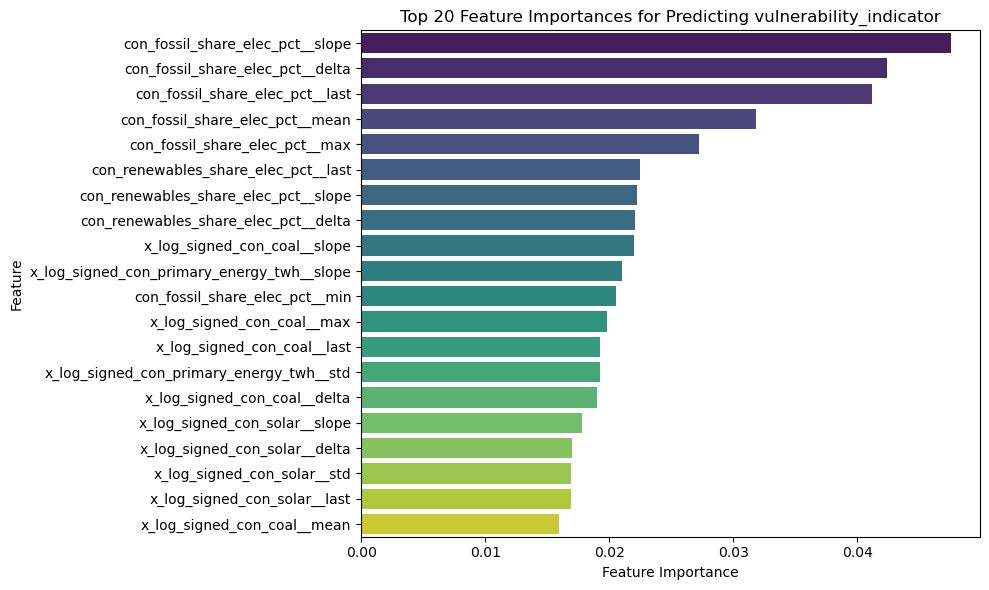

,target_col,n_rows,n_train,n_test,class_0,class_1,status,n_features,baseline_accuracy,test_accuracy,test_balanced_accuracy,test_precision,test_recall,test_f1,test_roc_auc,mean_importance,median_importance,max_importance
0,vulnerability_indicator,997,797,200,467,530,trained,172,0.53,0.865,0.863609,0.862385,0.886792,0.874419,0.939884,0.005814,0.002955,0.047514


In [82]:
# Plot top 10 features by importance for the target variable
RandomForestDiscovery.plot_feature_importance(
    feature_importance_df,
    top_n=20
)
rf_training_summary_df


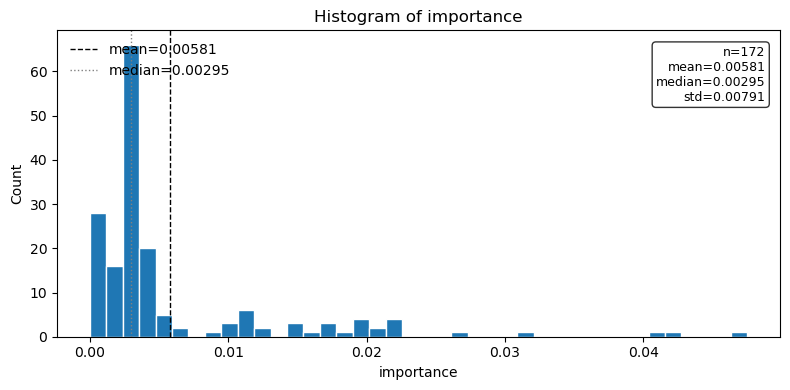

<Axes: title={'center': 'Histogram of importance'}, xlabel='importance', ylabel='Count'>

In [83]:
RandomForestDiscovery.plot_feature_importance_histogram(feature_importance_df, "importance", bins=40, kde=False, annotate_stats=True)

### Select Top Features and Create Scatter Plot

In [84]:
# Add to feature_name to top_feature_counts_df
feature_importance_df['feature_standard_name'] = feature_importance_df["feature"].apply(lambda x: x.split("__")[0] if "__" in x else x)

# sort by importance to see top features
feature_importance_df = feature_importance_df.sort_values("importance", ascending=False)
feature_importance_df.head(20)

,target_col,feature,importance,feature_standard_name
94,vulnerability_indicator,con_fossil_share_elec_pct__slope,0.047514,con_fossil_share_elec_pct
93,vulnerability_indicator,con_fossil_share_elec_pct__delta,0.042428,con_fossil_share_elec_pct
92,vulnerability_indicator,con_fossil_share_elec_pct__last,0.041150,con_fossil_share_elec_pct
88,vulnerability_indicator,con_fossil_share_elec_pct__mean,0.031865,con_fossil_share_elec_pct
91,vulnerability_indicator,con_fossil_share_elec_pct__max,0.027204,con_fossil_share_elec_pct
99,vulnerability_indicator,con_renewables_share_elec_pct__last,0.022455,con_renewables_share_elec_pct
101,vulnerability_indicator,con_renewables_share_elec_pct__slope,0.022241,con_renewables_share_elec_pct
100,vulnerability_indicator,con_renewables_share_elec_pct__delta,0.022074,con_renewables_share_elec_pct
129,vulnerability_indicator,x_log_signed_con_coal__slope,0.022018,x_log_signed_con_coal
108,vulnerability_indicator,x_log_signed_con_primary_energy_twh__slope,0.021021,x_log_signed_con_primary_energy_twh


In [85]:
feature_importance_df.to_clipboard(index=False)

In [86]:
selected_features = rf_discovery.select_top_features(
    feature_importance_df,
    feature_standard_name_col="feature_standard_name",
    top_k=2,
)
print("Selected features for scenario discovery:", selected_features)

Selected features for scenario discovery: ['con_fossil_share_elec_pct', 'con_renewables_share_elec_pct']


In [87]:
selected_features = selected_features + ["cap_govt_effectiveness"]

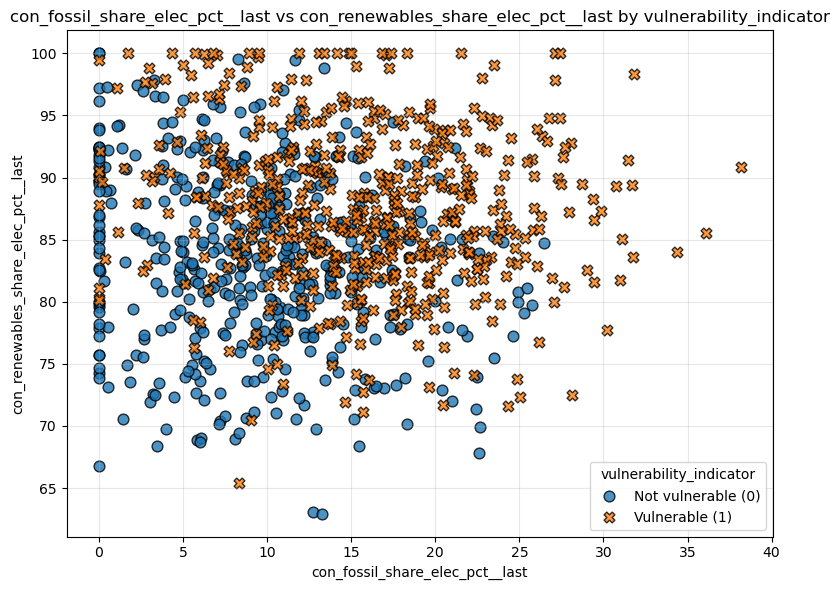

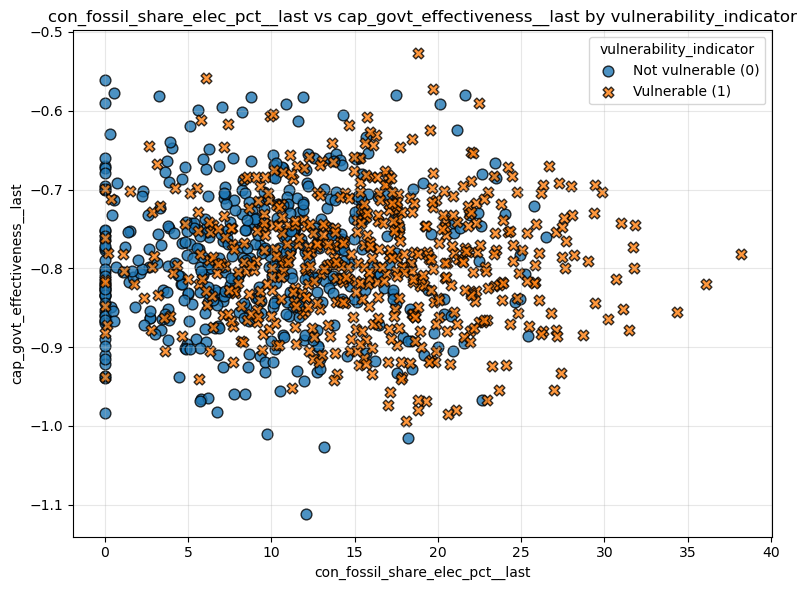

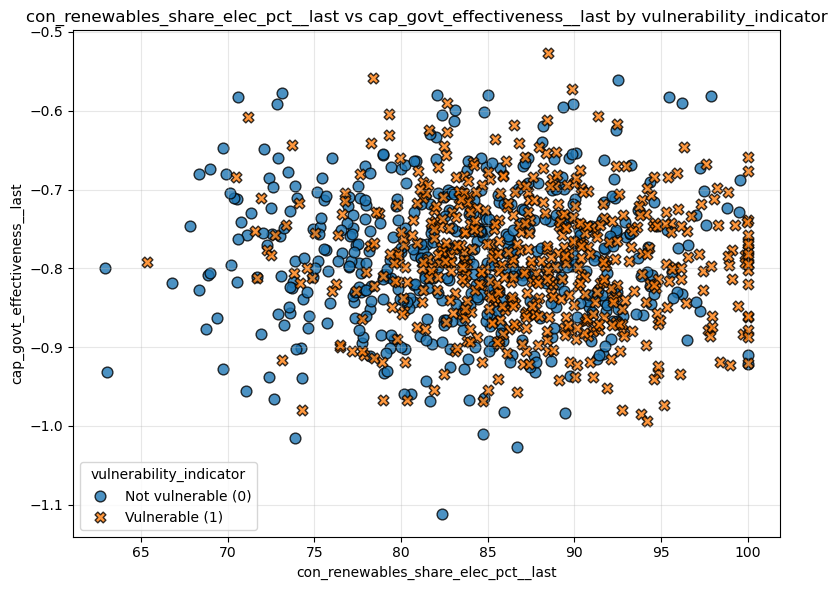

In [88]:
# Pairwise scatter plots for the selected features
for x_feat, y_feat in combinations(selected_features, 2):
    VulnerabilityAnalyzer.plot_xy_by_vulnerability(
        merged_df,
        x=x_feat + "__last",
        y=y_feat + "__last",
        vuln_col="vulnerability_indicator",
    )

### Optimization


In [89]:
# Optimization utilities are now provided by ScenarioDiscoveryOptimizer.


In [90]:
optimizer = ScenarioDiscoveryOptimizer(
    lower=0.1,
    upper=0.9,
    popsize=200,
    generations=200,
    seed=55555,
)


In [91]:
pt, optimization_results, cmp_selected = optimizer.optimize(
    merged_df,
    selected_features,
    vuln_col="vulnerability_indicator",
)

if "POST_PROCESSING_DIR_PATH" in globals():
    optimization_results.to_csv(
        os.path.join(POST_PROCESSING_DIR_PATH, "sd_optimization_results.csv"),
        index=False,
    )

optimization_results.head()


,con_fossil_share_elec_pct__last,con_renewables_share_elec_pct__last,cap_govt_effectiveness__last,coverage,density,con_fossil_share_elec_pct__last__cutoff,con_renewables_share_elec_pct__last__cutoff,cap_govt_effectiveness__last__cutoff,comparators
0,0.100125,0.100187,0.899865,0.841509,0.608458,3.239654,76.205676,-0.683754,"[>, >, <]"
1,0.100125,0.100187,0.899995,0.841509,0.608458,3.239654,76.205676,-0.683735,"[>, >, <]"
2,0.105095,0.100187,0.899993,0.839623,0.609589,3.406676,76.205676,-0.683735,"[>, >, <]"
3,0.105878,0.100125,0.897670,0.837736,0.610729,3.440027,76.192675,-0.684138,"[>, >, <]"
4,0.121003,0.100000,0.899982,0.835849,0.616992,3.906822,76.166570,-0.683737,"[>, >, <]"


In [92]:
optimization_results.head()


,con_fossil_share_elec_pct__last,con_renewables_share_elec_pct__last,cap_govt_effectiveness__last,coverage,density,con_fossil_share_elec_pct__last__cutoff,con_renewables_share_elec_pct__last__cutoff,cap_govt_effectiveness__last__cutoff,comparators
0,0.100125,0.100187,0.899865,0.841509,0.608458,3.239654,76.205676,-0.683754,"[>, >, <]"
1,0.100125,0.100187,0.899995,0.841509,0.608458,3.239654,76.205676,-0.683735,"[>, >, <]"
2,0.105095,0.100187,0.899993,0.839623,0.609589,3.406676,76.205676,-0.683735,"[>, >, <]"
3,0.105878,0.100125,0.897670,0.837736,0.610729,3.440027,76.192675,-0.684138,"[>, >, <]"
4,0.121003,0.100000,0.899982,0.835849,0.616992,3.906822,76.166570,-0.683737,"[>, >, <]"


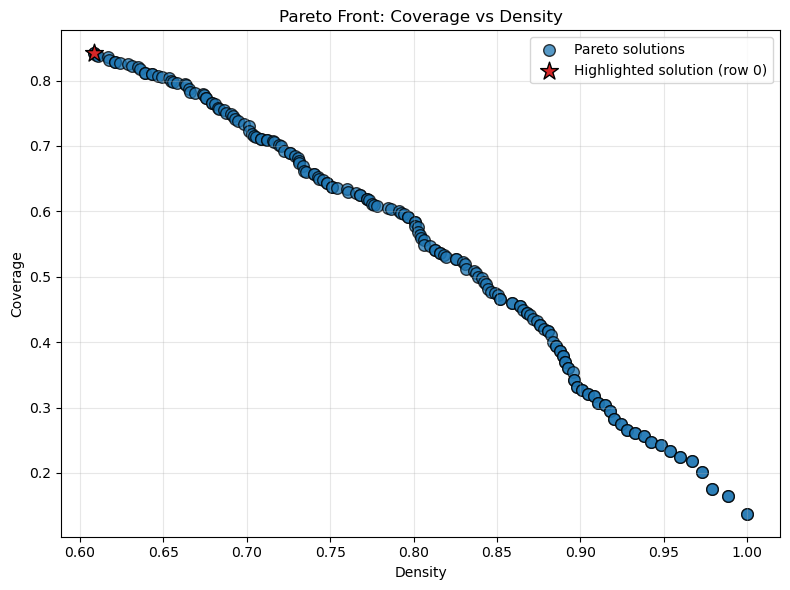

<Axes: title={'center': 'Pareto Front: Coverage vs Density'}, xlabel='Density', ylabel='Coverage'>

In [93]:
ScenarioDiscoveryOptimizer.plot_pareto_front(optimization_results, annotate=False)


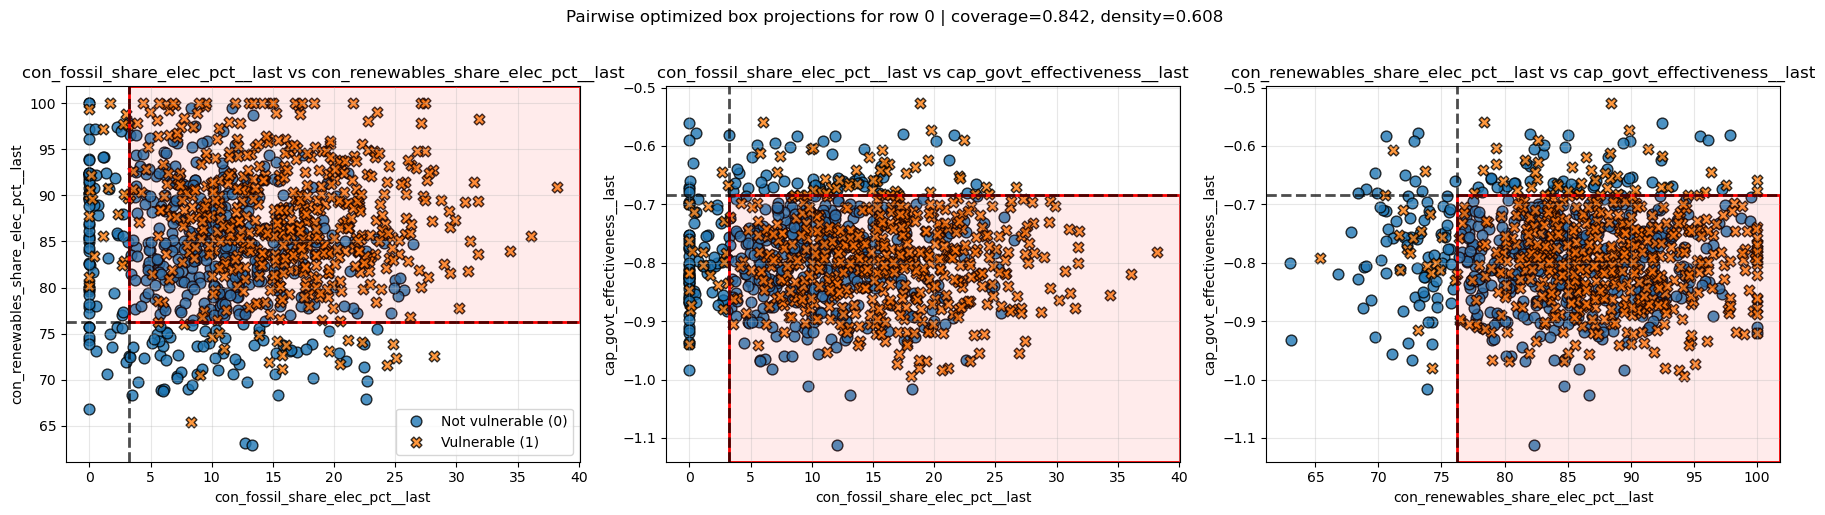

{'row_idx': 0,
 'mode': 'pairwise',
 'driver_cols': ['con_fossil_share_elec_pct__last',
  'con_renewables_share_elec_pct__last',
  'cap_govt_effectiveness__last'],
 'pairs': [{'x_col': 'con_fossil_share_elec_pct__last',
   'y_col': 'con_renewables_share_elec_pct__last',
   'cutoff_x': 3.2396538884367936,
   'cutoff_y': 76.20567586867001,
   'comparators': {'con_fossil_share_elec_pct__last': '>',
    'con_renewables_share_elec_pct__last': '>'}},
  {'x_col': 'con_fossil_share_elec_pct__last',
   'y_col': 'cap_govt_effectiveness__last',
   'cutoff_x': 3.2396538884367936,
   'cutoff_y': -0.683754120044788,
   'comparators': {'con_fossil_share_elec_pct__last': '>',
    'cap_govt_effectiveness__last': '<'}},
  {'x_col': 'con_renewables_share_elec_pct__last',
   'y_col': 'cap_govt_effectiveness__last',
   'cutoff_x': 76.20567586867001,
   'cutoff_y': -0.683754120044788,
   'comparators': {'con_renewables_share_elec_pct__last': '>',
    'cap_govt_effectiveness__last': '<'}}]}

In [94]:
ScenarioDiscoveryOptimizer.plot_boxed_scatter_from_optimization_result(
    pt,
    optimization_results,
    row_idx=0,
)
